In [79]:
import pandas as pd 
import seaborn as sns, matplotlib.pyplot as plt 
import scipy.stats as stats
import ast

url = 'https://raw.githubusercontent.com/nkmwicz/worldcup2018data/refs/heads/main/cleaned_events_world_cup2018.csv'
df = pd.read_csv(url)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0


In [80]:
# to compare correlation between shots, passes and winning status. We need to do win as one and 
# loss/draw as zero. This will be a t test and then we do an anova for all three

df['eventName'].unique ()

array(['Pass', 'Duel', 'Free Kick', 'Foul', 'Others on the ball', 'Shot',
       'Save attempt', 'Offside', 'Goalkeeper leaving line'], dtype=object)

In [81]:
df['pass'] = (df['eventName'] == 'Pass').astype(int)
df['shot'] = (df['eventName'] == 'Shot').astype(int)
df.head(1)

,eventId,subEventName,tags,playerId,matchId,eventName,teamId,matchPeriod,eventSec,subEventId,id,x1,y1,x2,y2,pass,shot
0,8,Simple pass,['Accurate'],Mohammad Ibrahim Al Sahlawi,"Russia - Saudi Arabia, 5 - 0",Pass,Saudi Arabia,1H,1.656214,Simple pass,258612104,50,50,35.0,53.0,1,0


In [82]:
df.groupby('matchId').first().reset_index()['matchId']

0        Argentina - Croatia, 0 - 3
1        Argentina - Iceland, 1 - 1
2           Australia - Peru, 0 - 2
3          Belgium - England, 2 - 0
4            Belgium - Japan, 3 - 2
                  ...              
59         Tunisia - England, 1 - 2
60          Uruguay - France, 0 - 2
61        Uruguay - Portugal, 2 - 1
62          Uruguay - Russia, 3 - 0
63    Uruguay - Saudi Arabia, 1 - 0
Name: matchId, Length: 64, dtype: object

In [83]:
def get_outcome(row):
    teamId = row['teamId']
    match = row['matchId']
    teams, scores = match.split(',')
    tm1, tm2 = teams.split(' - ')
    score1, score2 = scores.split(' - ')
    score2 = score2.split('(')[0]
    #0 is the index notation, only calling the first of the two 
    score1 = int(score1)
    score2 = int(score2)

    if teamId == tm1: 
        if score1 > score2:
            return 'win'
        elif score1 < score2: 
            return 'loss'
        else: 
            return 'draw' 
    else: #team2 == teamId
        if score2 > score1:
            return 'win'
        elif score1 > score2: 
            return 'loss'
        else: 
            return 'draw' 
#argument is row because axis = 1, therefore each row will be checked for the outcome,
#rather than column by column, which is default.
df['outcome'] = df.apply(get_outcome, axis=1)

In [84]:
df.groupby(['matchId', 'teamId']).agg({'outcome': 'first'}).value_counts()

outcome
loss       51
win        51
draw       26
Name: count, dtype: int64

In [85]:
group_df = df.groupby(['matchId', 'teamId']).agg(
    shots = ('shot', 'sum'),
    passes = ('pass', 'sum'), 
    outcome = ('outcome', 'first'),
).reset_index()
group_df

,matchId,teamId,shots,passes,outcome
0,"Argentina - Croatia, 0 - 3",Argentina,10,476,loss
1,"Argentina - Croatia, 0 - 3",Croatia,13,334,win
2,"Argentina - Iceland, 1 - 1",Argentina,22,744,draw
3,"Argentina - Iceland, 1 - 1",Iceland,8,183,draw
4,"Australia - Peru, 0 - 2",Australia,11,512,loss
...,...,...,...,...,...
123,"Uruguay - Portugal, 2 - 1",Uruguay,6,238,win
124,"Uruguay - Russia, 3 - 0",Russia,3,327,loss
125,"Uruguay - Russia, 3 - 0",Uruguay,12,466,win
126,"Uruguay - Saudi Arabia, 1 - 0",Saudi Arabia,7,553,loss


In [86]:
def run_anova(df, num_col, cat_col):
    """
    Run an Anova on a pandas dataframe on the chosen 
    categorical column and numerical column
    
    Args:
        df (Pandas DataFrame): The pandas DataFrame.
        num_col (str): name of the column of the numerical data.
        cat_col (str): name of the column of the categorical data.
        
    Returns:
        (f, p, critical): the f-stat, p-value, and critical-f    
    """
    cats = df[cat_col].unique()
    samples = [df.loc[df[cat_col] == c, num_col] for c in cats]
    f, p = stats.f_oneway(*samples)

    alpha = 0.05
    dfb = len(samples) - 1 
    dfw = sum([len(s) for s in samples]) - len(samples)
    crit_f = stats.f.ppf(1-alpha, dfb, dfw) # samples = a list of lists => [[],[],[]]
    
    return (f,p,crit_f)

In [87]:
f,p,cf = run_anova(df = group_df, cat_col = "outcome", num_col = "shots")
print(f"f={f:.4f}, p={p:.4f}, crit_f={cf:.4f}")

f=1.2489, p=0.2904, crit_f=3.0687


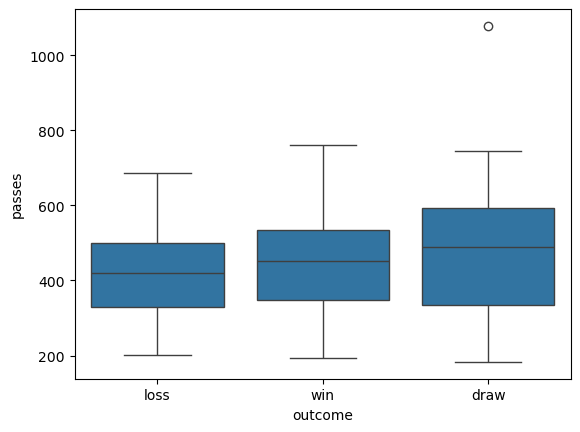

In [88]:
box = sns.boxplot(data = group_df, x = 'outcome', y = 'passes')

In [89]:
def run_ttest(cat_col, num_col):
    p_losers = group_df.loc[group_df[cat_col] == "loss", num_col]
    p_n_losers = group_df.loc[group_df[cat_col] != "loss", num_col]

    alpha = 0.05
    t, p = stats.ttest_ind(p_losers, p_n_losers)
    deg_f = len(p_losers) + len(p_n_losers) - 2
    ct = stats.t.ppf(1-alpha/2, deg_f)
    return (t,p,ct)

In [90]:
t,p,ct = run_ttest(cat_col = "outcome", num_col = "shots")
print(f"t={t:.4f}, p={p:.4f}, critical_t={ct:.4f}")

t=-1.5688, p=0.1192, critical_t=1.9790


In [91]:
x_max = 120
y_max = 75
m3_start = .33 * x_max
a3_start = .66 * x_max
# x2 must be in field loc
def get_loc(x):
    if x < m3_start:
        return "d3"
    elif x < a3_start:
        return "m3"
    else:
        return "a3"

df["field_loc"] = df["x2"].apply(get_loc)
print(m3_start, a3_start)
df.sample(5)[["x2", "field_loc"]]

39.6 79.2


,x2,field_loc
80263,80.0,a3
96422,63.0,m3
74071,30.0,d3
99611,48.0,m3
53829,53.0,m3


In [92]:
df["field_loc"].isna().sum()

np.int64(0)

In [93]:
df["field_loc"].value_counts()

field_loc
m3    51996
d3    34951
a3    14812
Name: count, dtype: int64

In [94]:
dfa3 = df.loc[df["field_loc"] == "a3"]
grp_dfa3 = dfa3.groupby(['matchId', 'teamId']).agg(
    shots = ('shot', 'sum'),
    passes = ('pass', 'sum'), 
    outcome = ('outcome', 'first'),
).reset_index()
f,p,cf = run_anova(grp_dfa3, cat_col="outcome", num_col="passes")
print(f"f={f:.4f}, p={p:.4f}, critical_f={cf:.4f}")

f=0.2297, p=0.7951, critical_f=3.0687
